# Lab 6 - Punto 2: Aprendizaje No Supervisado sobre OrganAMNIST

**Dataset:** OrganAMNIST — imágenes médicas de órganos (28×28 píxeles, escala de grises).  
Tratamos el dataset como **completamente no etiquetado** durante el entrenamiento.  
Las etiquetas reales solo se usan para **evaluación** y para **simular el oráculo** en aprendizaje activo.

**Flujo del notebook:**
1. Carga y exploración del dataset  
2. Reducción de dimensionalidad con PCA  
3. K-Means directamente sobre el dataset  
4. Método del codo (Inertia)  
5. Silhouette Score y diagramas de silueta  
6. Etiquetado manual de imágenes representativas  
7. Aprendizaje semi-supervisado con propagación de etiquetas  
8. Aprendizaje activo iterativo

---
## 0. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator, FixedFormatter

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

np.random.seed(42)


---
## 1. Carga y exploración del dataset OrganAMNIST

OrganAMNIST contiene imágenes de TAC de órganos abdominales con **11 clases** diferentes.
- Cada imagen: **28 × 28 píxeles** → **784 características** (n >> 10 ✅)
- Miles de ejemplos de entrenamiento (m >> 10,000 ✅)

In [2]:
DATA_DIR = '/mnt/disk-d/Ing_Sistemas/Septimo_Semestre/1_IA/Datasets/5_organamnist'

train_images = np.load(f'{DATA_DIR}/train_images.npy')
train_labels = np.load(f'{DATA_DIR}/train_labels.npy')
test_images  = np.load(f'{DATA_DIR}/test_images.npy')
test_labels  = np.load(f'{DATA_DIR}/test_labels.npy')

print(f'Entrenamiento : {train_images.shape[0]:>6} imágenes  |  forma: {train_images.shape}')
print(f'Prueba        : {test_images.shape[0]:>6} imágenes  |  forma: {test_images.shape}')
print(f'Clases únicas : {np.unique(train_labels)}')
print(f'Total clases  : {np.unique(train_labels).size}')


Entrenamiento :  34561 imágenes  |  forma: (34561, 28, 28)
Prueba        :  17778 imágenes  |  forma: (17778, 28, 28)
Clases únicas : [ 0  1  2  3  4  5  6  7  8  9 10]
Total clases  : 11


Diccionario con los nombres de las 11 clases de OrganAMNIST y visualización de ejemplos por clase.

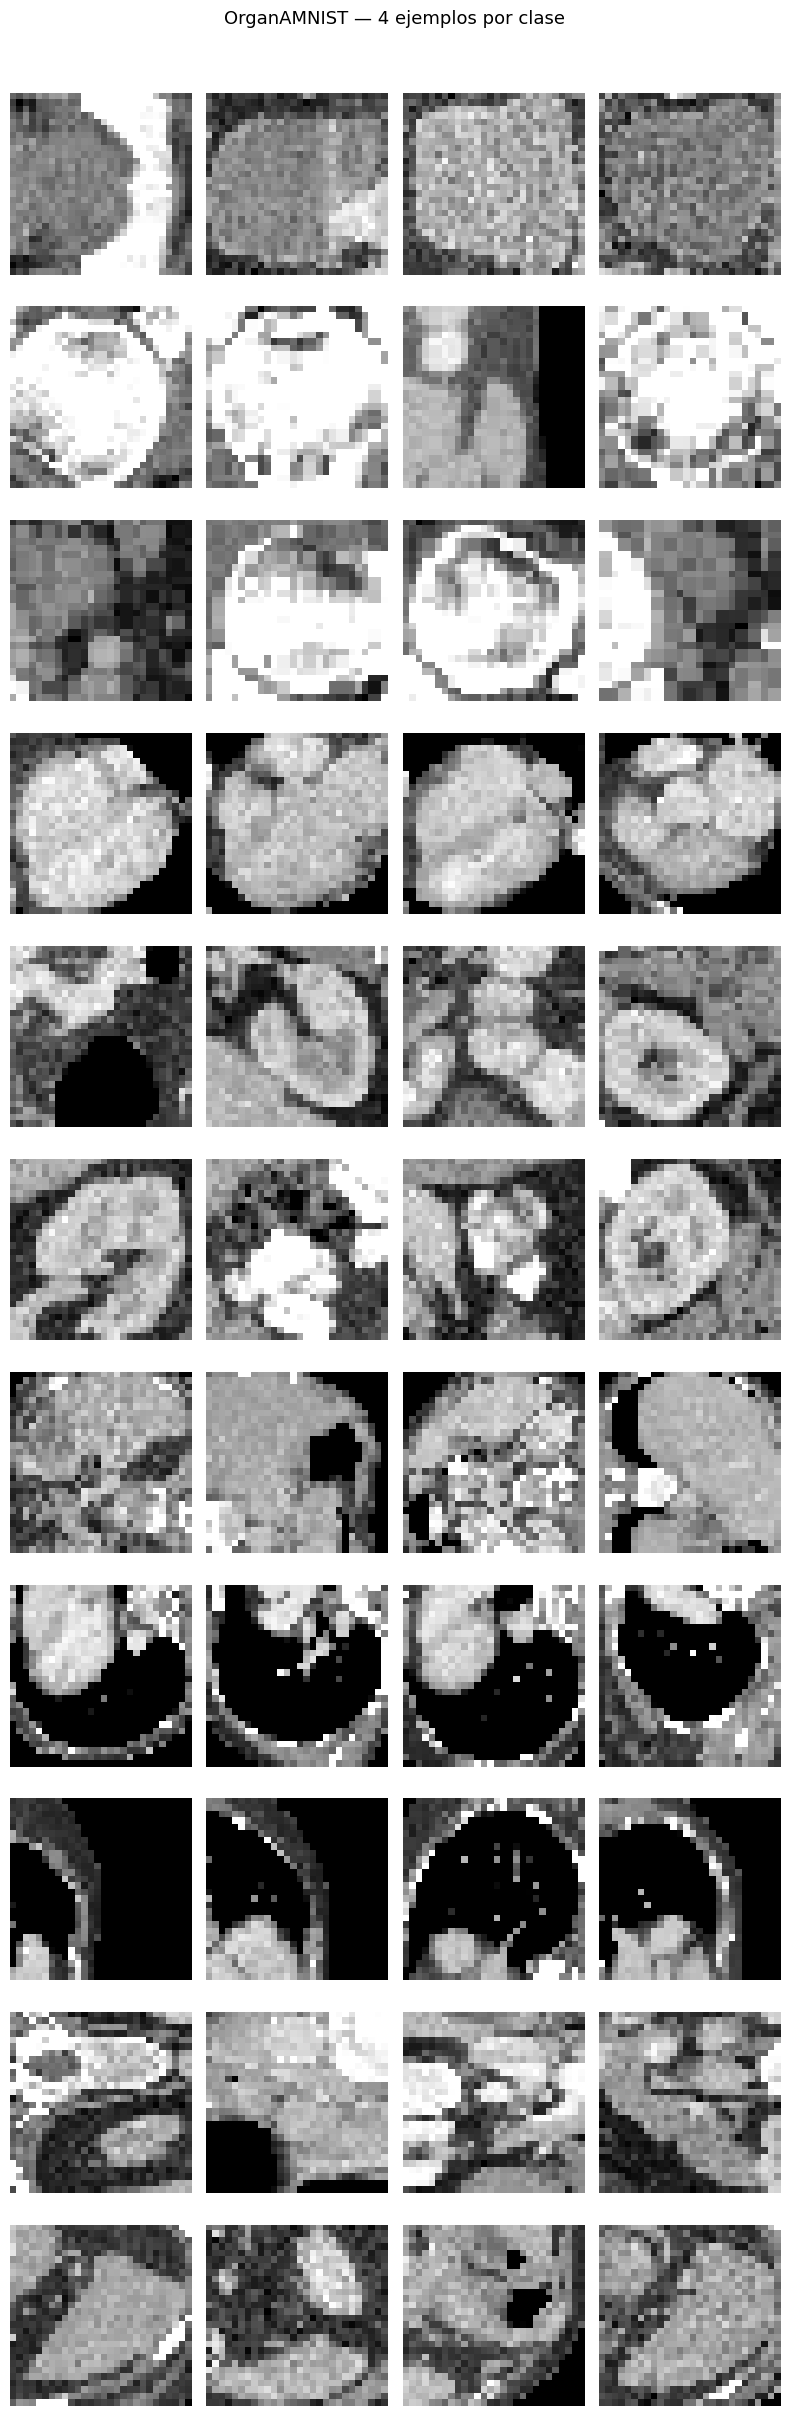

In [ ]:
NOMBRES_CLASES = {
    0: 'Vejiga',
    1: 'Fémur-izq',
    2: 'Fémur-der',
    3: 'Corazón',
    4: 'Riñón-izq',
    5: 'Riñón-der',
    6: 'Hígado',
    7: 'Pulmón-izq',
    8: 'Pulmón-der',
    9: 'Bazo',
    10: 'Aorta'
}
fig, axes = plt.subplots(11, 4, figsize=(8, 24))
for clase in range(11):
    idxs = np.where(train_labels.flatten() == clase)[0][:4]
    for col, idx in enumerate(idxs):
        axes[clase, col].imshow(train_images[idx], cmap='gray')
        axes[clase, col].axis('off')
        if col == 0:
            axes[clase, col].set_ylabel(f'{clase}: {NOMBRES_CLASES[clase]}',
                                        fontsize=9, rotation=0,
                                        labelpad=60, va='center')
plt.suptitle('OrganAMNIST — 4 ejemplos por clase', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


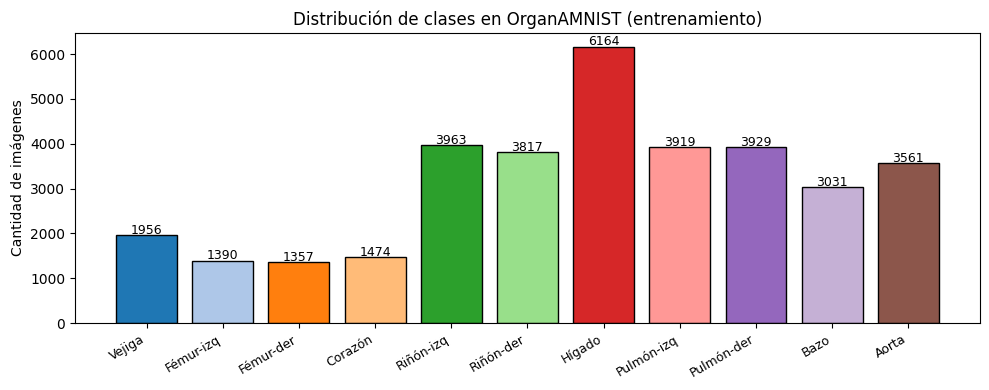

In [ ]:
clases, conteos = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10, 4))
bars = plt.bar([NOMBRES_CLASES[c] for c in clases], conteos,
               color=plt.cm.tab20.colors[:11], edgecolor='black')
for bar, cnt in zip(bars, conteos):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(cnt), ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de clases en OrganAMNIST (entrenamiento)')
plt.tight_layout()
plt.show()


Aplanar imágenes 28×28 → vectores de 784 características y normalizar píxeles a [0, 1].

In [5]:
X_train = train_images.reshape(train_images.shape[0], -1).astype('float32') / 255.0
X_test  = test_images.reshape(test_images.shape[0], -1).astype('float32') / 255.0
y_train = train_labels.flatten()
y_test  = test_labels.flatten()

print(f'X_train: {X_train.shape}  →  {X_train.shape[0]} ejemplos × {X_train.shape[1]} características')
print(f'X_test : {X_test.shape}')


X_train: (34561, 784)  →  34561 ejemplos × 784 características
X_test : (17778, 784)


---
## 2. Reducción de dimensionalidad con PCA

Con 784 características, K-Means en espacio completo es lento y sufre de la **maldición de la dimensionalidad** (las distancias se vuelven menos informativas en alta dimensión). Reducimos a **50 componentes principales** que retienen la mayoría de la varianza, acelerando el clustering sin perder información relevante.

Curva de varianza acumulada para decidir cuántos componentes PCA retener.

Varianza explicada con 50 componentes: 77.7%


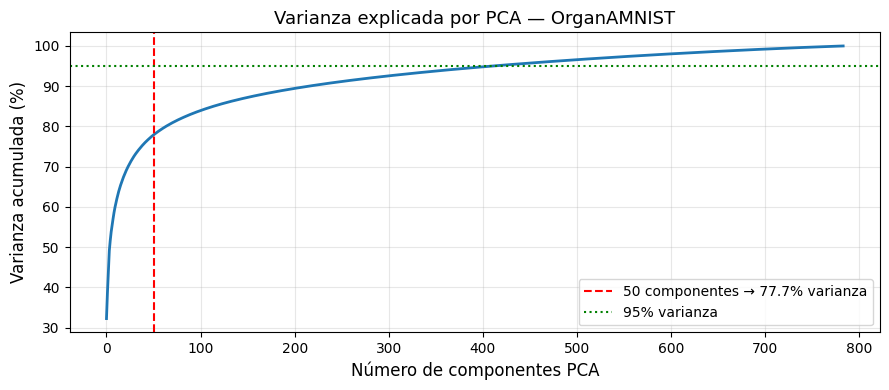

In [6]:
N_COMPONENTES = 50

pca = PCA(n_components=N_COMPONENTES, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

varianza_acumulada = np.sum(pca.explained_variance_ratio_) * 100
print(f'Varianza explicada con {N_COMPONENTES} componentes: {varianza_acumulada:.1f}%')

pca_full = PCA(random_state=42).fit(X_train)
plt.figure(figsize=(9, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_) * 100, linewidth=2)
plt.axvline(x=N_COMPONENTES, color='r', linestyle='--',
            label=f'{N_COMPONENTES} componentes → {varianza_acumulada:.1f}% varianza')
plt.axhline(y=95, color='g', linestyle=':', label='95% varianza')
plt.xlabel('Número de componentes PCA', fontsize=12)
plt.ylabel('Varianza acumulada (%)', fontsize=12)
plt.title('Varianza explicada por PCA — OrganAMNIST', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Visualización 2D con las 2 primeras componentes principales, coloreado por clase real.

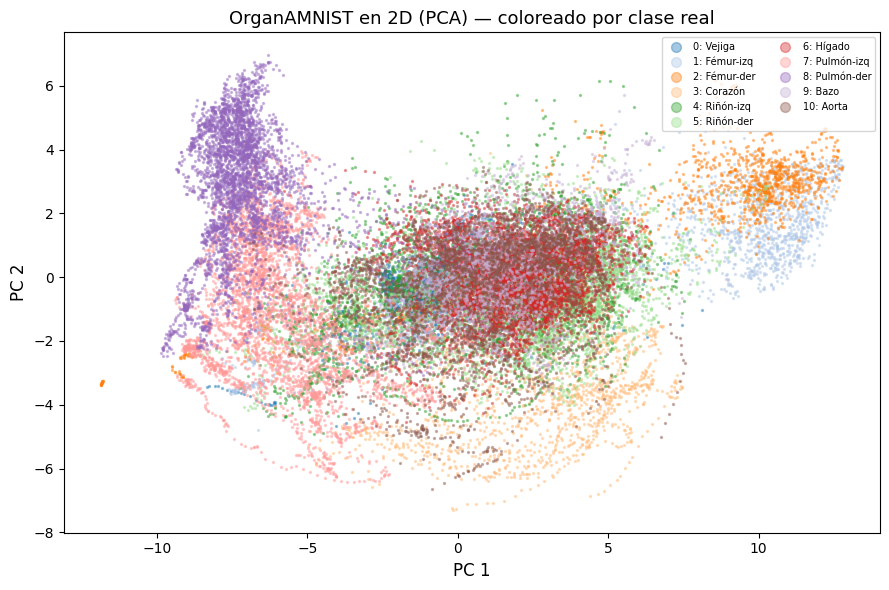

In [7]:
pca2 = PCA(n_components=2, random_state=42)
X_train_2d = pca2.fit_transform(X_train)

plt.figure(figsize=(9, 6))
colores = plt.cm.tab20.colors
for clase in range(11):
    mask = y_train == clase
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                s=2, alpha=0.4, color=colores[clase],
                label=f'{clase}: {NOMBRES_CLASES[clase]}')
plt.xlabel('PC 1', fontsize=12)
plt.ylabel('PC 2', fontsize=12)
plt.title('OrganAMNIST en 2D (PCA) — coloreado por clase real', fontsize=13)
plt.legend(loc='upper right', fontsize=7, markerscale=5, ncol=2)
plt.tight_layout()
plt.show()


---
## 3. K-Means sobre OrganAMNIST

Aplicamos K-Means sobre las características reducidas con PCA. Dado que sabemos que el dataset tiene 11 clases reales, empezamos explorando desde k=2 hasta k=20.

Aplicar K-Means con k=11 (número real de clases) para visualización inicial: comparación de clases reales vs clusters.

K-Means con k=11 aplicado sobre 34561 imágenes
Inercia: 858196.06


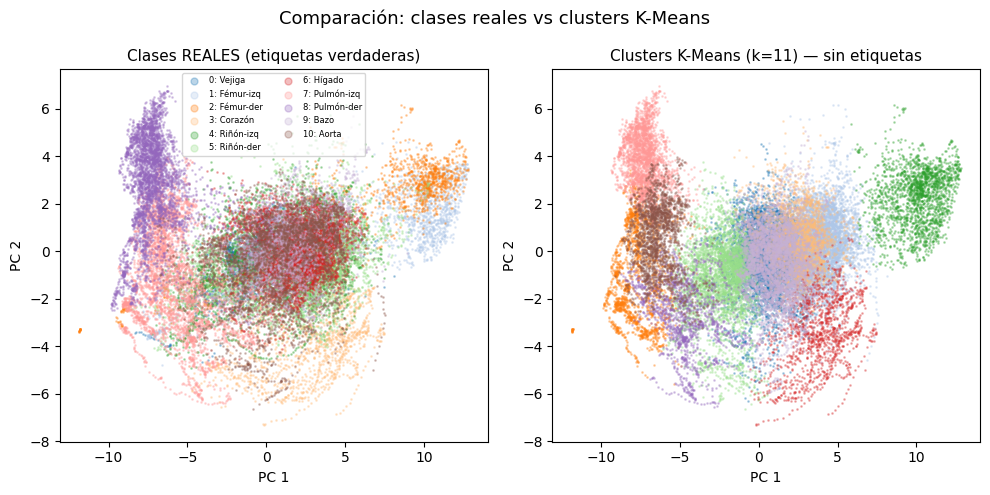

In [8]:
k_real = 11
kmeans_11 = KMeans(n_clusters=k_real, random_state=42, n_init=5)
kmeans_11.fit(X_train_pca)

print(f'K-Means con k={k_real} aplicado sobre {X_train_pca.shape[0]} imágenes')
print(f'Inercia: {kmeans_11.inertia_:.2f}')

labels_11 = kmeans_11.labels_

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
for clase in range(11):
    mask = y_train == clase
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                s=1, alpha=0.3, color=colores[clase],
                label=f'{clase}: {NOMBRES_CLASES[clase]}')
plt.title('Clases REALES (etiquetas verdaderas)', fontsize=11)
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.legend(fontsize=6, markerscale=5, ncol=2)

plt.subplot(1, 2, 2)
for cluster in range(k_real):
    mask = labels_11 == cluster
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                s=1, alpha=0.3, color=colores[cluster])
plt.title(f'Clusters K-Means (k={k_real}) — sin etiquetas', fontsize=11)
plt.xlabel('PC 1'); plt.ylabel('PC 2')

plt.suptitle('Comparación: clases reales vs clusters K-Means', fontsize=13)
plt.tight_layout()
plt.show()


---
## 4. Método del Codo (Inertia)

La **inercia** mide la suma de distancias al cuadrado de cada punto a su centroide. A medida que $k$ crece, la inercia baja. Buscamos el punto donde la curva "dobla" — el **codo** — que indica el valor óptimo de $k$.

> Usamos **MiniBatchKMeans** para acelerar el cómputo sobre el dataset completo.

In [9]:
K_MAX = 20
inertias = []

print(f'Entrenando K-Means de k=1 a k={K_MAX}...')
kmeans_por_k = []
for k in range(1, K_MAX + 1):
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=1024)
    km.fit(X_train_pca)
    kmeans_por_k.append(km)
    inertias.append(km.inertia_)
    print(f'  k={k:2d} | Inertia: {km.inertia_:>12.1f}')

print('\nListo.')


Entrenando K-Means de k=1 a k=20...
  k= 1 | Inertia:    1831168.4
  k= 2 | Inertia:    1332261.8
  k= 3 | Inertia:    1182597.8
  k= 4 | Inertia:    1094570.0
  k= 5 | Inertia:    1035455.9
  k= 6 | Inertia:    1005157.0
  k= 7 | Inertia:     979126.9
  k= 8 | Inertia:     926645.6
  k= 9 | Inertia:     921994.3
  k=10 | Inertia:     888194.2
  k=11 | Inertia:     858687.8
  k=12 | Inertia:     851623.6
  k=13 | Inertia:     842873.9
  k=14 | Inertia:     825722.3
  k=15 | Inertia:     813937.2
  k=16 | Inertia:     805249.4
  k=17 | Inertia:     796206.9
  k=18 | Inertia:     781807.2
  k=19 | Inertia:     779110.2
  k=20 | Inertia:     764416.2

Listo.


Marcar el codo en k=11 (número real de clases del dataset).

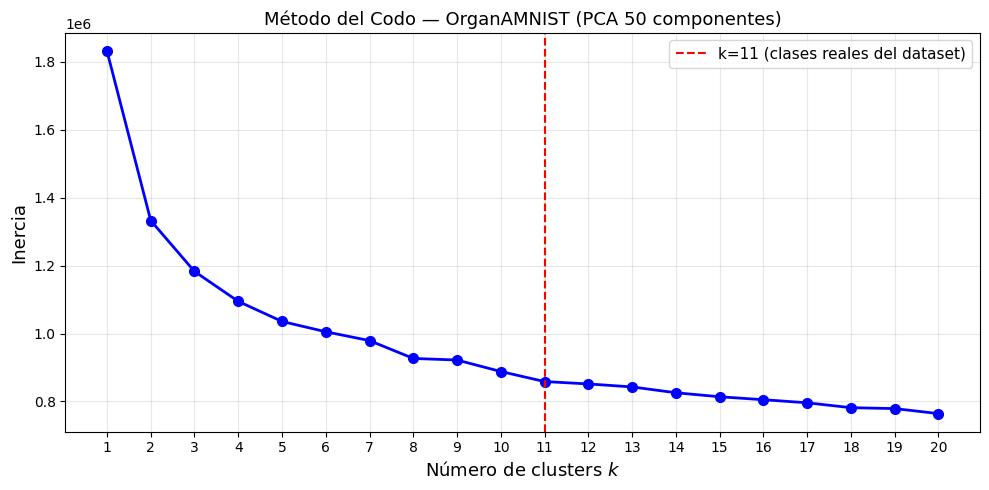

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, K_MAX + 1), inertias, 'bo-', linewidth=2, markersize=7)

plt.axvline(x=11, color='red', linestyle='--', linewidth=1.5,
            label='k=11 (clases reales del dataset)')

plt.xlabel('Número de clusters $k$', fontsize=13)
plt.ylabel('Inercia', fontsize=13)
plt.title('Método del Codo — OrganAMNIST (PCA 50 componentes)', fontsize=13)
plt.xticks(range(1, K_MAX + 1))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 5. Silhouette Score y Diagramas de Silueta

El **silhouette score** mide qué tan bien separados están los clusters. Para cada punto se calcula:
$$s = \frac{b - a}{\max(a, b)}$$
donde $a$ = distancia media a puntos del mismo cluster, $b$ = distancia media al cluster vecino más cercano.

- **Cercano a +1**: el punto está bien asignado
- **Cercano a 0**: el punto está en la frontera entre clusters
- **Negativo**: el punto probablemente está mal asignado

> Usamos una muestra de 3000 imágenes para que el cómputo sea eficiente.

Calcular silhouette scores sobre una muestra de 3000 imágenes para eficiencia.

In [11]:
N_MUESTRA = 3000
sample_ixs = np.random.choice(len(X_train_pca), N_MUESTRA, replace=False)
X_muestra  = X_train_pca[sample_ixs]

print(f'Calculando silhouette scores sobre {N_MUESTRA} muestras...')
silhouette_scores = []
for k in range(2, K_MAX + 1):
    etiquetas_muestra = kmeans_por_k[k - 1].predict(X_muestra)
    if len(np.unique(etiquetas_muestra)) >= 2:
        score = silhouette_score(X_muestra, etiquetas_muestra)
    else:
        score = 0
    silhouette_scores.append(score)
    print(f'  k={k:2d} | Silhouette: {score:.4f}')

mejor_k = np.argmax(silhouette_scores) + 2
print(f'\n→ Mejor k según silhouette: {mejor_k}')


Calculando silhouette scores sobre 3000 muestras...
  k= 2 | Silhouette: 0.2313
  k= 3 | Silhouette: 0.2087
  k= 4 | Silhouette: 0.1245
  k= 5 | Silhouette: 0.1164
  k= 6 | Silhouette: 0.1046
  k= 7 | Silhouette: 0.1125
  k= 8 | Silhouette: 0.1144
  k= 9 | Silhouette: 0.1027
  k=10 | Silhouette: 0.1162
  k=11 | Silhouette: 0.1025
  k=12 | Silhouette: 0.1033
  k=13 | Silhouette: 0.1006
  k=14 | Silhouette: 0.0964
  k=15 | Silhouette: 0.0966
  k=16 | Silhouette: 0.0849
  k=17 | Silhouette: 0.0968
  k=18 | Silhouette: 0.0978
  k=19 | Silhouette: 0.0956
  k=20 | Silhouette: 0.0900

→ Mejor k según silhouette: 2


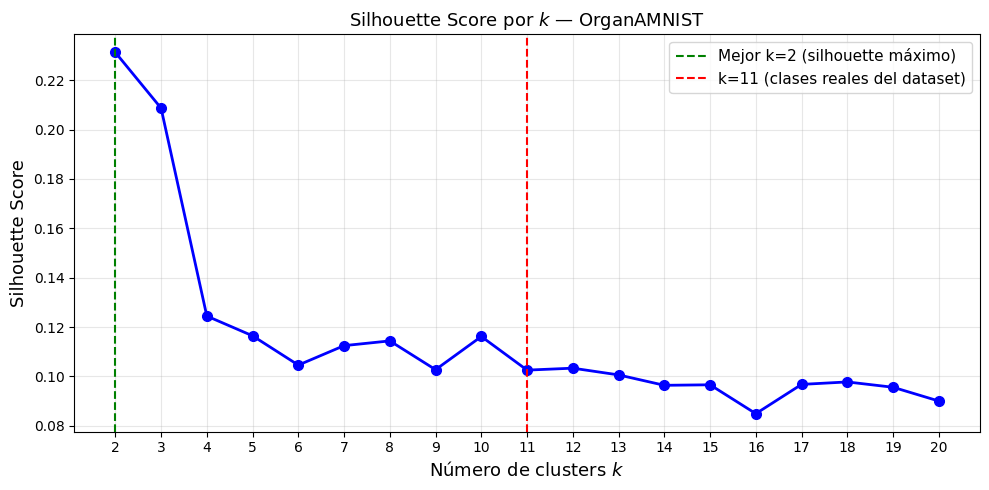

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(range(2, K_MAX + 1), silhouette_scores, 'bo-', linewidth=2, markersize=7)

plt.axvline(x=mejor_k, color='green', linestyle='--', linewidth=1.5,
            label=f'Mejor k={mejor_k} (silhouette máximo)')
plt.axvline(x=11, color='red', linestyle='--', linewidth=1.5,
            label='k=11 (clases reales del dataset)')

plt.xlabel('Número de clusters $k$', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.title('Silhouette Score por $k$ — OrganAMNIST', fontsize=13)
plt.xticks(range(2, K_MAX + 1))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Diagramas de silueta para el mejor k y sus vecinos, más k=11 (clases reales).

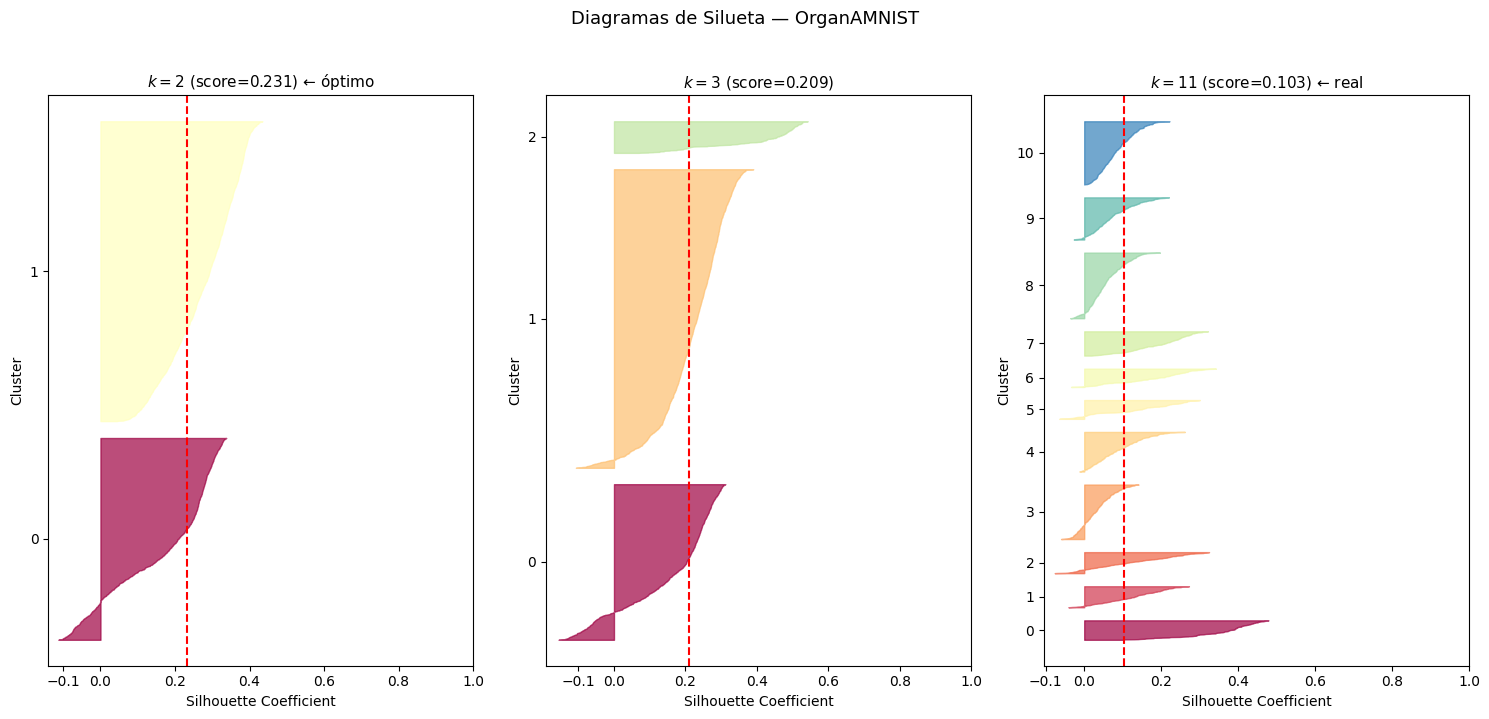

In [13]:
ks_candidatos = sorted(set([mejor_k - 1, mejor_k, mejor_k + 1, 11]))
ks_candidatos = [k for k in ks_candidatos if 2 <= k <= K_MAX]

n_plots = len(ks_candidatos)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 7))
if n_plots == 1:
    axes = [axes]

for ax, k in zip(axes, ks_candidatos):
    etiquetas_muestra = kmeans_por_k[k - 1].predict(X_muestra)
    coefs_silueta = silhouette_samples(X_muestra, etiquetas_muestra)
    score_medio = silhouette_scores[k - 2] if k - 2 < len(silhouette_scores) else 0

    padding = N_MUESTRA // 30
    pos = padding
    ticks = []

    for i in range(k):
        coeffs = coefs_silueta[etiquetas_muestra == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        ax.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FixedFormatter(range(k)))
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xlabel('Silhouette Coefficient', fontsize=10)
    ax.set_ylabel('Cluster', fontsize=10)
    ax.axvline(x=score_medio, color='red', linestyle='--', linewidth=1.5)
    etiqueta_extra = ' ← óptimo' if k == mejor_k else (' ← real' if k == 11 else '')
    ax.set_title(f'$k={k}$ (score={score_medio:.3f}){etiqueta_extra}', fontsize=11)

plt.suptitle('Diagramas de Silueta — OrganAMNIST', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Selección del k para semi-supervisado y etiquetado manual

Para el aprendizaje semi-supervisado usamos **k=50 clusters** (más que el número de clases reales). Esto permite identificar imágenes representativas **más refinadas** de cada subgrupo visual, y el proceso de propagación cubre mejor la diversidad interna de cada clase.

In [14]:
K_SEMI = 50

print(f'Entrenando K-Means con k={K_SEMI} para aprendizaje semi-supervisado...')
kmeans_semi = KMeans(n_clusters=K_SEMI, random_state=42, n_init=3)
X_dist = kmeans_semi.fit_transform(X_train_pca)   # (n_train, 50)
print(f'Listo. Forma de matriz de distancias: {X_dist.shape}')

idxs_representativos = np.argmin(X_dist, axis=0)  # 50 índices
X_representativas    = X_train[idxs_representativos]   # imágenes en píxeles (no PCA)

print(f'Imágenes representativas seleccionadas: {X_representativas.shape}')


Entrenando K-Means con k=50 para aprendizaje semi-supervisado...
Listo. Forma de matriz de distancias: (34561, 50)
Imágenes representativas seleccionadas: (50, 784)


Visualizar las 50 imágenes representativas (más cercanas a cada centroide) con su índice de cluster.

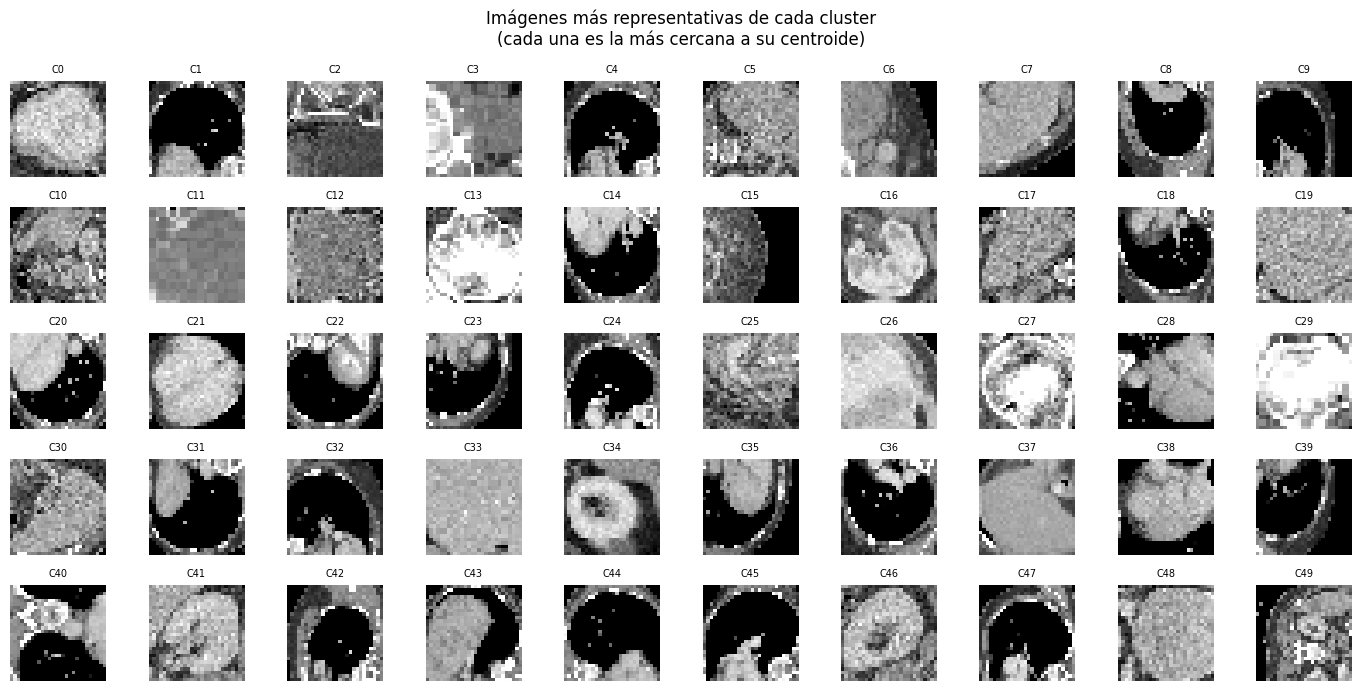


Revisa cada imagen y completa el diccionario de etiquetado manual en la siguiente celda.
Clases disponibles: {0: 'Vejiga', 1: 'Fémur-izq', 2: 'Fémur-der', 3: 'Corazón', 4: 'Riñón-izq', 5: 'Riñón-der', 6: 'Hígado', 7: 'Pulmón-izq', 8: 'Pulmón-der', 9: 'Bazo', 10: 'Aorta'}


In [15]:
fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for idx_cluster, ax in enumerate(axes.ravel()):
    ax.imshow(X_representativas[idx_cluster].reshape(28, 28), cmap='gray')
    ax.set_title(f'C{idx_cluster}', fontsize=7)
    ax.axis('off')
plt.suptitle('Imágenes más representativas de cada cluster\n'
             '(cada una es la más cercana a su centroide)', fontsize=12)
plt.tight_layout()
plt.show()
print('\nRevisa cada imagen y completa el diccionario de etiquetado manual en la siguiente celda.')
print('Clases disponibles:', NOMBRES_CLASES)


---
## 7. Etiquetado manual de imágenes representativas

Este es el paso donde el **experto humano** mira cada imagen representativa y asigna la etiqueta que corresponde. En un caso real esto es lo que haría un médico o radiólogo.

Completa el diccionario `ETIQUETAS_MANUALES` con el número de clase correcto para cada cluster **C0, C1, ..., C49** según lo que veas en el gráfico anterior.

**Clases:**
```
0: Vejiga  | 1: Fémur-izq | 2: Fémur-der | 3: Corazón   | 4: Riñón-izq
5: Riñón-der | 6: Hígado  | 7: Pulmón-izq | 8: Pulmón-der | 9: Bazo | 10: Aorta
```

In [16]:

ETIQUETAS_MANUALES = {
     0: -1,  1: -1,  2: -1,  3: -1,  4: -1,
     5: -1,  6: -1,  7: -1,  8: -1,  9: -1,
    10: -1, 11: -1, 12: -1, 13: -1, 14: -1,
    15: -1, 16: -1, 17: -1, 18: -1, 19: -1,
    20: -1, 21: -1, 22: -1, 23: -1, 24: -1,
    25: -1, 26: -1, 27: -1, 28: -1, 29: -1,
    30: -1, 31: -1, 32: -1, 33: -1, 34: -1,
    35: -1, 36: -1, 37: -1, 38: -1, 39: -1,
    40: -1, 41: -1, 42: -1, 43: -1, 44: -1,
    45: -1, 46: -1, 47: -1, 48: -1, 49: -1,
}

sin_asignar = [c for c, v in ETIQUETAS_MANUALES.items() if v == -1]
if sin_asignar:
    print(f'⚠️  Clusters sin etiquetar: {sin_asignar}')
    print('   Completa el diccionario para continuar.')
else:
    print('✅ Todos los clusters tienen etiqueta manual asignada.')
    clases_asignadas = np.array([ETIQUETAS_MANUALES[c] for c in range(K_SEMI)])
    for clase in range(11):
        n = np.sum(clases_asignadas == clase)
        print(f'   Clase {clase} ({NOMBRES_CLASES[clase]}): {n} clusters')


⚠️  Clusters sin etiquetar: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
   Completa el diccionario para continuar.


In [17]:
y_representativas_reales = y_train[idxs_representativos]

if not sin_asignar:
    y_representativas = np.array([ETIQUETAS_MANUALES[c] for c in range(K_SEMI)])
    print('Usando etiquetas MANUALES')
else:
    y_representativas = y_representativas_reales
    print('Usando etiquetas REALES (oráculo simulado) — completa ETIQUETAS_MANUALES para usar tu etiquetado')

print(f'Etiquetas asignadas a las {K_SEMI} imágenes representativas:')
for i, (et_manual, et_real) in enumerate(zip(y_representativas, y_representativas_reales)):
    marca = '✅' if et_manual == et_real else '❌'
    print(f'  C{i:02d}: manual={et_manual} ({NOMBRES_CLASES.get(et_manual,"?")}) | '
          f'real={et_real} ({NOMBRES_CLASES[et_real]}) {marca}')


Usando etiquetas REALES (oráculo simulado) — completa ETIQUETAS_MANUALES para usar tu etiquetado
Etiquetas asignadas a las 50 imágenes representativas:
  C00: manual=0 (Vejiga) | real=0 (Vejiga) ✅
  C01: manual=8 (Pulmón-der) | real=8 (Pulmón-der) ✅
  C02: manual=0 (Vejiga) | real=0 (Vejiga) ✅
  C03: manual=2 (Fémur-der) | real=2 (Fémur-der) ✅
  C04: manual=8 (Pulmón-der) | real=8 (Pulmón-der) ✅
  C05: manual=6 (Hígado) | real=6 (Hígado) ✅
  C06: manual=2 (Fémur-der) | real=2 (Fémur-der) ✅
  C07: manual=10 (Aorta) | real=10 (Aorta) ✅
  C08: manual=7 (Pulmón-izq) | real=7 (Pulmón-izq) ✅
  C09: manual=8 (Pulmón-der) | real=8 (Pulmón-der) ✅
  C10: manual=6 (Hígado) | real=6 (Hígado) ✅
  C11: manual=2 (Fémur-der) | real=2 (Fémur-der) ✅
  C12: manual=0 (Vejiga) | real=0 (Vejiga) ✅
  C13: manual=2 (Fémur-der) | real=2 (Fémur-der) ✅
  C14: manual=7 (Pulmón-izq) | real=7 (Pulmón-izq) ✅
  C15: manual=0 (Vejiga) | real=0 (Vejiga) ✅
  C16: manual=4 (Riñón-izq) | real=4 (Riñón-izq) ✅
  C17: manual

---
## 8. Aprendizaje Semi-supervisado

Con las **50 etiquetas** (manuales o del oráculo) aplicamos tres estrategias:

| Estrategia | Etiquetas usadas |
|---|---|
| Baseline: 50 aleatorias | 50 reales (aleatorias) |
| Semi-sup: 50 representativas | 50 manuales/reales (las mejores) |
| Propagación de etiquetas | 50 → propagadas a todo el train |


In [18]:
log_aleatorio = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
log_aleatorio.fit(X_train_pca[:50], y_train[:50])
acc_aleatorio = log_aleatorio.score(X_test_pca, y_test)
print(f'Baseline — 50 muestras aleatorias   : {acc_aleatorio:.4f}')


Baseline — 50 muestras aleatorias   : 0.4090


In [19]:
X_rep_pca = X_train_pca[idxs_representativos]

log_representativo = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
log_representativo.fit(X_rep_pca, y_representativas)
acc_representativo = log_representativo.score(X_test_pca, y_test)
print(f'Semi-sup  — 50 representativas      : {acc_representativo:.4f}')
print(f'  Mejora sobre aleatorio            : +{acc_representativo - acc_aleatorio:.4f}')


Semi-sup  — 50 representativas      : 0.4994
  Mejora sobre aleatorio            : +0.0904


Propagación de etiquetas: asignar a cada miembro del cluster la etiqueta de su representante. Calcular cuántas propagaciones son incorrectas (ruido).

In [20]:
y_propagado = np.empty(len(X_train_pca), dtype=int)
for i in range(K_SEMI):
    y_propagado[kmeans_semi.labels_ == i] = y_representativas[i]

precision_propagacion = np.mean(y_propagado == y_train)
print(f'Precisión de la propagación vs etiquetas reales: {precision_propagacion:.4f}')
print(f'→ {(1 - precision_propagacion)*100:.1f}% de las etiquetas propagadas son incorrectas (ruido)')


Precisión de la propagación vs etiquetas reales: 0.5880
→ 41.2% de las etiquetas propagadas son incorrectas (ruido)


Entrenar modelos con diferentes tamaños del pool propagado y guardar el de 1000 muestras para aprendizaje activo.

In [21]:
tamanos = [200, 500, 1000, 3000, len(X_train_pca)]
accs_propagado = []

for n in tamanos:
    lr = LogisticRegression(solver='lbfgs', max_iter=3000, random_state=42)
    lr.fit(X_train_pca[:n], y_propagado[:n])
    acc = lr.score(X_test_pca, y_test)
    accs_propagado.append(acc)
    print(f'  Propagado con n={n:>6}: accuracy = {acc:.4f}')

log_propagado = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
log_propagado.fit(X_train_pca[:1000], y_propagado[:1000])
acc_propagado = log_propagado.score(X_test_pca, y_test)
print(f'\nModelo propagado (1000 muestras): {acc_propagado:.4f}')


  Propagado con n=   200: accuracy = 0.4360
  Propagado con n=   500: accuracy = 0.4636
  Propagado con n=  1000: accuracy = 0.4739
  Propagado con n=  3000: accuracy = 0.4781
  Propagado con n= 34561: accuracy = 0.4846

Modelo propagado (1000 muestras): 0.4739


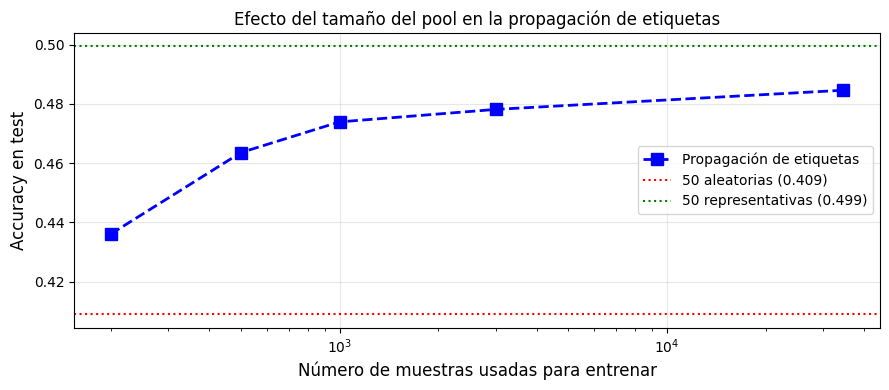

In [22]:
plt.figure(figsize=(9, 4))
plt.plot(tamanos, accs_propagado, 'bs--', linewidth=2, markersize=8,
         label='Propagación de etiquetas')
plt.axhline(acc_aleatorio, color='r', linestyle=':', linewidth=1.5,
            label=f'50 aleatorias ({acc_aleatorio:.3f})')
plt.axhline(acc_representativo, color='g', linestyle=':', linewidth=1.5,
            label=f'50 representativas ({acc_representativo:.3f})')
plt.xlabel('Número de muestras usadas para entrenar', fontsize=12)
plt.ylabel('Accuracy en test', fontsize=12)
plt.title('Efecto del tamaño del pool en la propagación de etiquetas', fontsize=12)
plt.legend(fontsize=10)
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 9. Aprendizaje Activo (*Active Learning*)

El aprendizaje activo es un proceso **iterativo**: el modelo identifica los ejemplos donde tiene **menor confianza**, y solicita que el oráculo (anotador humano) los etiquete correctamente. Así mejora más rápido que etiquetando aleatoriamente.

**Estrategia usada:** *Uncertainty Sampling* — en cada ronda se seleccionan los $q$ ejemplos con la **probabilidad máxima más baja** (el modelo está más "dudoso" sobre ellos).

In [23]:
def ronda_activa(modelo, X_pool, y_pool_true, y_pool_actual,
                 X_test, y_test, n_query=50):
    """
    Ejecuta una ronda de aprendizaje activo.

    Parámetros
    ----------
    modelo         : clasificador sklearn ya entrenado
    X_pool         : características del pool de entrenamiento
    y_pool_true    : etiquetas REALES del pool (simula el oráculo humano)
    y_pool_actual  : etiquetas actuales (propagadas + correcciones previas)
    X_test, y_test : conjunto de prueba
    n_query        : cuántos ejemplos corregir en esta ronda

    Retorna
    -------
    nuevo_modelo   : modelo reentrenado
    y_actualizado  : etiquetas con las correcciones del oráculo
    accuracy       : accuracy en test del nuevo modelo
    confianza_media: confianza media de los ejemplos consultados (antes de corrección)
    """
    probas = modelo.predict_proba(X_pool)

    confianza = np.max(probas, axis=1)

    indices_inciertos = np.argsort(confianza)[:n_query]
    confianza_media = confianza[indices_inciertos].mean()

    y_actualizado = y_pool_actual.copy()
    y_actualizado[indices_inciertos] = y_pool_true[indices_inciertos]

    nuevo_modelo = LogisticRegression(solver='lbfgs', max_iter=3000, random_state=42)
    nuevo_modelo.fit(X_pool, y_actualizado)
    accuracy = nuevo_modelo.score(X_test, y_test)

    return nuevo_modelo, y_actualizado, accuracy, confianza_media, indices_inciertos


Configuración del bucle de aprendizaje activo:
- Pool de 1000 muestras
- 50 etiquetas consultadas al oráculo por ronda
- 6 rondas iterativas

El oráculo corrige etiquetas usando las etiquetas reales del train.

In [24]:
N_POOL   = 1000    # muestras en el pool
N_QUERY  = 50      # etiquetas a pedir al oráculo por ronda
N_RONDAS = 6       # número de rondas

X_pool_act    = X_train_pca[:N_POOL]
y_pool_true   = y_train[:N_POOL]          # oráculo = etiquetas reales del TRAIN
y_pool_actual = y_propagado[:N_POOL].copy()  # empezamos con etiquetas propagadas

modelo_activo = LogisticRegression(solver='lbfgs', max_iter=3000, random_state=42)
modelo_activo.fit(X_pool_act, y_pool_actual)
acc_inicial   = modelo_activo.score(X_test_pca, y_test)

historial_acc        = [acc_inicial]
historial_confianza  = [np.max(modelo_activo.predict_proba(X_pool_act), axis=1).mean()]
etiquetas_reales_usadas = [0]

print(f'Accuracy inicial (propagación pura): {acc_inicial:.4f}')
print('=' * 60)

for ronda in range(1, N_RONDAS + 1):
    modelo_activo, y_pool_actual, acc, conf_media, inc_ixs = ronda_activa(
        modelo_activo, X_pool_act, y_pool_true, y_pool_actual,
        X_test_pca, y_test, n_query=N_QUERY
    )
    historial_acc.append(acc)
    historial_confianza.append(conf_media)
    etiquetas_reales_usadas.append(ronda * N_QUERY)

    print(f'Ronda {ronda:02d}/{N_RONDAS} | '
          f'Etiquetas oracle: {ronda*N_QUERY:>4} | '
          f'Confianza media: {conf_media:.4f} | '
          f'Accuracy: {acc:.4f}')

print('=' * 60)
print(f'Accuracy final: {historial_acc[-1]:.4f}')


Accuracy inicial (propagación pura): 0.4739
Ronda 01/6 | Etiquetas oracle:   50 | Confianza media: 0.3741 | Accuracy: 0.4801
Ronda 02/6 | Etiquetas oracle:  100 | Confianza media: 0.3485 | Accuracy: 0.4916
Ronda 03/6 | Etiquetas oracle:  150 | Confianza media: 0.3442 | Accuracy: 0.4942
Ronda 04/6 | Etiquetas oracle:  200 | Confianza media: 0.3424 | Accuracy: 0.4959
Ronda 05/6 | Etiquetas oracle:  250 | Confianza media: 0.3423 | Accuracy: 0.4971
Ronda 06/6 | Etiquetas oracle:  300 | Confianza media: 0.3414 | Accuracy: 0.4959
Accuracy final: 0.4959


Visualizar las 50 imágenes con menor confianza del modelo final. Verde = predicción correcta, Rojo = incorrecta.

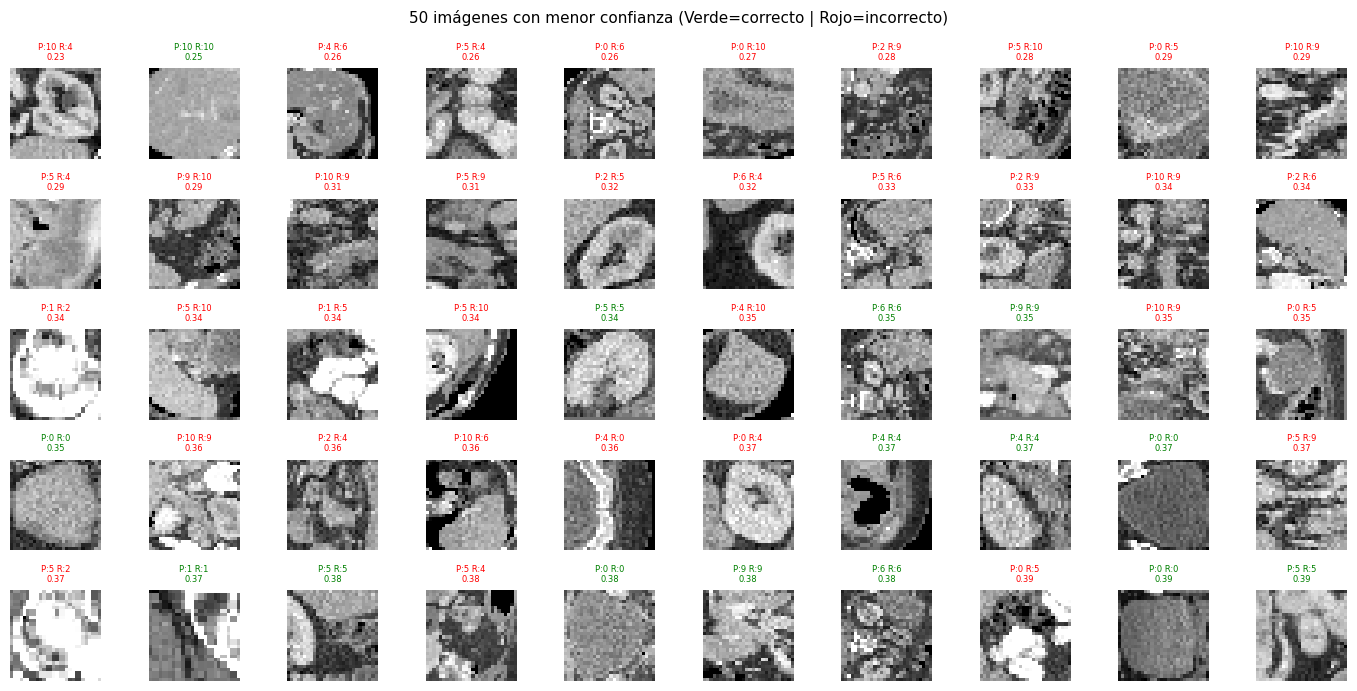

In [25]:
probas_final     = modelo_activo.predict_proba(X_pool_act)
confianza_final  = np.max(probas_final, axis=1)
mas_inciertos    = np.argsort(confianza_final)[:50]
predicciones     = np.argmax(probas_final, axis=1)

fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for ax, ix in zip(axes.ravel(), mas_inciertos):
    ax.imshow(X_train[ix].reshape(28, 28), cmap='gray')
    pred  = predicciones[ix]
    real  = y_pool_true[ix]
    conf  = confianza_final[ix]
    color = 'green' if pred == real else 'red'
    ax.set_title(f'P:{pred} R:{real}\n{conf:.2f}', fontsize=6, color=color)
    ax.axis('off')
plt.suptitle('50 imágenes con menor confianza (Verde=correcto | Rojo=incorrecto)', fontsize=11)
plt.tight_layout()
plt.show()


Curva de aprendizaje activo: evolución del accuracy y confianza del modelo por ronda.

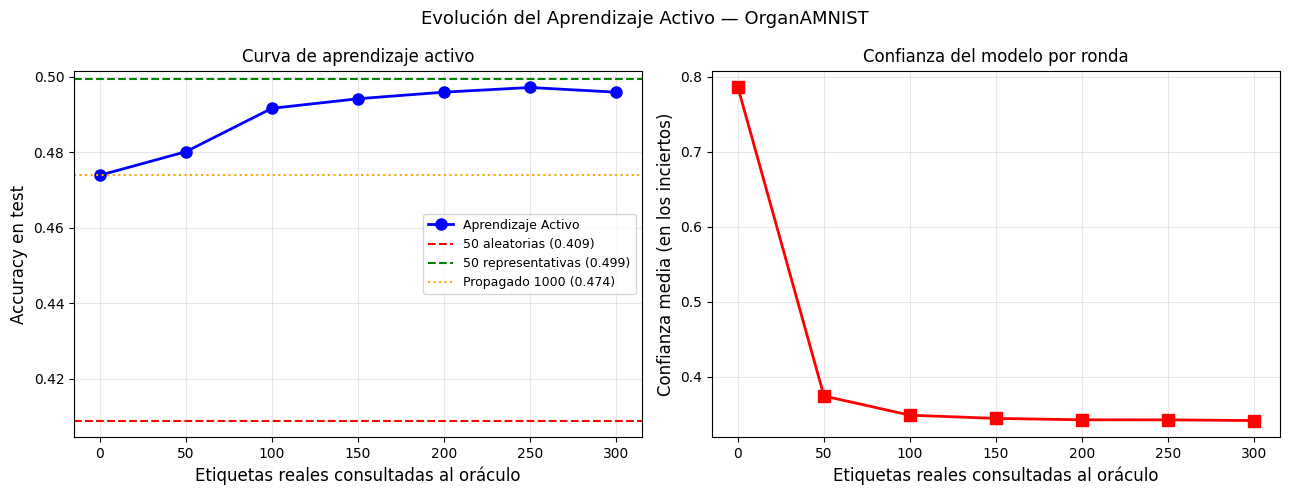

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(etiquetas_reales_usadas, historial_acc,
             'bo-', linewidth=2, markersize=8, label='Aprendizaje Activo')
axes[0].axhline(acc_aleatorio,      color='r', linestyle='--',
                label=f'50 aleatorias ({acc_aleatorio:.3f})')
axes[0].axhline(acc_representativo, color='g', linestyle='--',
                label=f'50 representativas ({acc_representativo:.3f})')
axes[0].axhline(acc_propagado,      color='orange', linestyle=':',
                label=f'Propagado 1000 ({acc_propagado:.3f})')
axes[0].set_xlabel('Etiquetas reales consultadas al oráculo', fontsize=12)
axes[0].set_ylabel('Accuracy en test', fontsize=12)
axes[0].set_title('Curva de aprendizaje activo', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(etiquetas_reales_usadas, historial_confianza,
             'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Etiquetas reales consultadas al oráculo', fontsize=12)
axes[1].set_ylabel('Confianza media (en los inciertos)', fontsize=12)
axes[1].set_title('Confianza del modelo por ronda', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evolución del Aprendizaje Activo — OrganAMNIST', fontsize=13)
plt.tight_layout()
plt.show()


---
## 10. Resumen final comparativo

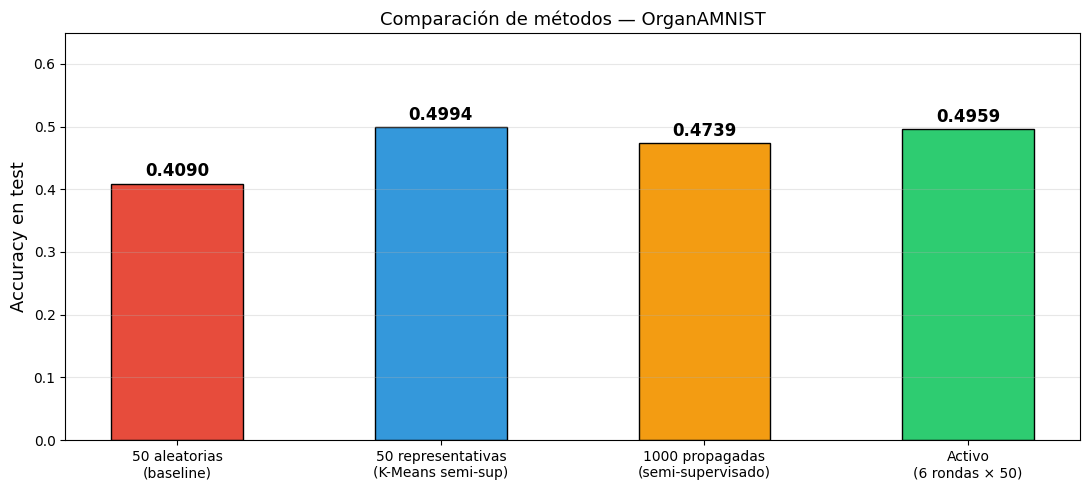


📊 Tabla resumen:
Método                                   Etiquetas reales usadas     Accuracy
------------------------------------------------------------------------------
50 muestras aleatorias (baseline)        50 reales                     0.4090
50 representativas (K-Means)             50 manuales/reales            0.4994
Propagación de etiquetas (1000)          50 → 1000 propagadas          0.4739
Aprendizaje Activo (6 rondas)            300 oracle + prop.            0.4959


In [27]:
resultados = {
    f'50 aleatorias\n(baseline)':                acc_aleatorio,
    f'50 representativas\n(K-Means semi-sup)':   acc_representativo,
    f'1000 propagadas\n(semi-supervisado)':       acc_propagado,
    f'Activo\n({N_RONDAS} rondas × {N_QUERY})':  historial_acc[-1],
}

colores_bar = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

plt.figure(figsize=(11, 5))
bars = plt.bar(resultados.keys(), resultados.values(),
               color=colores_bar, edgecolor='black', width=0.5)
for bar, val in zip(bars, resultados.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom',
             fontsize=12, fontweight='bold')
plt.ylim(0, min(1.0, max(resultados.values()) + 0.15))
plt.ylabel('Accuracy en test', fontsize=13)
plt.title('Comparación de métodos — OrganAMNIST', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n📊 Tabla resumen:')
print(f'{"Método":<40} {"Etiquetas reales usadas":<25} {"Accuracy":>10}')
print('-' * 78)
datos_tabla = [
    ('50 muestras aleatorias (baseline)',    '50 reales',                        acc_aleatorio),
    ('50 representativas (K-Means)',         '50 manuales/reales',               acc_representativo),
    ('Propagación de etiquetas (1000)',      f'50 → {N_POOL} propagadas',         acc_propagado),
    (f'Aprendizaje Activo ({N_RONDAS} rondas)', f'{N_RONDAS*N_QUERY} oracle + prop.', historial_acc[-1]),
]
for metodo, etiq, acc in datos_tabla:
    print(f'{metodo:<40} {etiq:<25} {acc:>10.4f}')
